Loading Libraries

In [2]:
import numpy as np
import pandas as pd
import pickle
import tensorflow
import sklearn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

2025-12-02 10:44:07.436201: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-02 10:44:07.530044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 10:44:10.852009: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Removing NANs and Splitting the data into train-test-split

In [4]:


# Load data
df = pd.read_csv("Classifier/training_data.csv")

label_cols = [
    'cluster_homogeneity',
    'malignant_label',
    'inflammation_label',
    'necrosis_label',
    'stromal_epithelium_ratio',
    'stromal_cellularity',
    'malignant_subtype',
    'second_malignant_subtype',
    'non_malignant_subtype',
    'second_non_malignant_subtype'
]

#removing nans to reduce confusion and possible bugs
df[label_cols] = df[label_cols].fillna("not_applicable")
for col in label_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

for col in label_cols:
    df[col] = df[col].replace("nan", "not_applicable")


# for col in label_cols:
#     df[col] = df[col].astype(str).str.strip().str.lower()

    
gss1 = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=42)

train_idx, temp_idx = next(gss1.split(df, groups=df["slides"]))

train_df = df.iloc[train_idx].copy()
temp_df  = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(test_size=0.50, n_splits=1, random_state=42)

val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["slides"]))

val_df  = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Val:",   val_df.shape)
print("Test:",  test_df.shape)

Train: (254781, 143)
Val: (55429, 143)
Test: (50357, 143)


In [5]:
for col in label_cols:
    print("\n=== ", col, " ===")
    print("Train:", set(train_df[col].unique()))
    print("Val:", set(val_df[col].unique()))
    print("Test:", set(test_df[col].unique()))


===  cluster_homogeneity  ===
Train: {'high (> 75%)', 'moderate (50 - 75%)'}
Val: {'high (> 75%)', 'moderate (50 - 75%)'}
Test: {'high (> 75%)', 'moderate (50 - 75%)'}

===  malignant_label  ===
Train: {'yes', 'no'}
Val: {'yes', 'no'}
Test: {'yes', 'no'}

===  inflammation_label  ===
Train: {'marked', 'none-sparse', 'mild-moderate'}
Val: {'marked', 'none-sparse', 'mild-moderate'}
Test: {'marked', 'none-sparse', 'mild-moderate'}

===  necrosis_label  ===
Train: {'universal', 'none', 'some'}
Val: {'universal', 'none', 'some'}
Test: {'universal', 'none', 'some'}

===  stromal_epithelium_ratio  ===
Train: {'more stroma', 'not_applicable', 'more epithelium', 'roughly equal'}
Val: {'more stroma', 'not_applicable', 'more epithelium', 'roughly equal'}
Test: {'more stroma', 'not_applicable', 'more epithelium', 'roughly equal'}

===  stromal_cellularity  ===
Train: {'not_applicable', 'moderate', 'high', 'low'}
Val: {'not_applicable', 'moderate', 'high', 'low'}
Test: {'not_applicable', 'high', '

In [6]:
print("Train ∩ Val:", set(train_df.slides) & set(val_df.slides))
print("Train ∩ Test:", set(train_df.slides) & set(test_df.slides))
print("Val ∩ Test:", set(val_df.slides) & set(test_df.slides))

Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


In [7]:
for col in label_cols:
    print(f"\n=== {col} ===")
    print(df.groupby(col)["slides"].nunique())


=== cluster_homogeneity ===
cluster_homogeneity
high (> 75%)           501
moderate (50 - 75%)    481
Name: slides, dtype: int64

=== malignant_label ===
malignant_label
no     501
yes    495
Name: slides, dtype: int64

=== inflammation_label ===
inflammation_label
marked           493
mild-moderate    500
none-sparse      501
Name: slides, dtype: int64

=== necrosis_label ===
necrosis_label
none         501
some         467
universal    365
Name: slides, dtype: int64

=== stromal_epithelium_ratio ===
stromal_epithelium_ratio
more epithelium    480
more stroma        491
not_applicable     501
roughly equal      493
Name: slides, dtype: int64

=== stromal_cellularity ===
stromal_cellularity
high              476
low               489
moderate          493
not_applicable    501
Name: slides, dtype: int64

=== malignant_subtype ===
malignant_subtype
acinar            493
cribriform        283
lepidic           364
not_applicable    501
papillary         366
solid             477
Name: s

In [8]:
meta_cols = ["slide_id", "tile_id", "row", "col", "coords", "hpc_id"]

for col in meta_cols:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
        val_df = val_df.drop(columns=[col])
        test_df = test_df.drop(columns=[col])

In [9]:
train_df[label_cols].head()

,cluster_homogeneity,malignant_label,inflammation_label,necrosis_label,stromal_epithelium_ratio,stromal_cellularity,malignant_subtype,second_malignant_subtype,non_malignant_subtype,second_non_malignant_subtype
0,high (> 75%),no,marked,none,not_applicable,not_applicable,not_applicable,not_applicable,collagenosis,not_applicable
1,high (> 75%),yes,mild-moderate,none,roughly equal,low,solid,micropapillary,not_applicable,not_applicable
2,high (> 75%),yes,none-sparse,none,more stroma,low,acinar,cribriform,collagenosis,not_applicable
3,high (> 75%),yes,mild-moderate,none,roughly equal,moderate,solid,acinar,not_applicable,not_applicable
4,high (> 75%),no,none-sparse,none,not_applicable,not_applicable,not_applicable,not_applicable,vessels (wall or lumen),not_applicable


Splitting into X and Y 

In [15]:
# Label columns (same as before)

# Feature columns = all z_*
feature_cols = [c for c in df.columns if c.startswith("z_")]

print("Features:", len(feature_cols))
print("Labels:", len(label_cols))

# TRAIN
X_train = train_df[feature_cols].values
Y_train = train_df[label_cols]

# VAL
X_val = val_df[feature_cols].values
Y_val = val_df[label_cols]

# TEST
X_test = test_df[feature_cols].values
Y_test = test_df[label_cols]


X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

Y_test_original  = Y_test.copy()

Features: 128
Labels: 10


Adding Label Encoder

In [40]:

encoders = {}

Y_train = Y_train.copy()
Y_val = Y_val.copy()
Y_test = Y_test.copy()

for col in label_cols:
    le = LabelEncoder()
    le.fit(Y_train[col])

    encoders[col] = le

    # transform training
    Y_train[col] = le.transform(Y_train[col])

    # safe transform val/test
    Y_val[col] = Y_val[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    Y_test[col] = Y_test[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

In [41]:
import joblib

# Save encoders
joblib.dump(encoders, "label_encoders.pkl")

# Save the order of label columns
joblib.dump(label_cols, "label_columns.pkl")

print("Saved encoders + label columns!")

Saved encoders + label columns!


In [43]:
import joblib

enc = joblib.load("label_encoders.pkl")
cols = joblib.load("label_columns.pkl")

print("Loaded encoders:", enc)
print("Loaded columns:", cols)

Loaded encoders: {'cluster_homogeneity': LabelEncoder(), 'malignant_label': LabelEncoder(), 'inflammation_label': LabelEncoder(), 'necrosis_label': LabelEncoder(), 'stromal_epithelium_ratio': LabelEncoder(), 'stromal_cellularity': LabelEncoder(), 'malignant_subtype': LabelEncoder(), 'second_malignant_subtype': LabelEncoder(), 'non_malignant_subtype': LabelEncoder(), 'second_non_malignant_subtype': LabelEncoder()}
Loaded columns: ['cluster_homogeneity', 'malignant_label', 'inflammation_label', 'necrosis_label', 'stromal_epithelium_ratio', 'stromal_cellularity', 'malignant_subtype', 'second_malignant_subtype', 'non_malignant_subtype', 'second_non_malignant_subtype']


Preparing Output Dictionaries for multihead model

In [12]:
label_cols = Y_train.columns.tolist()

y_train_dict = {col: Y_train[col].values for col in label_cols}
y_val_dict   = {col: Y_val[col].values for col in label_cols}
y_test_dict  = {col: Y_test[col].values for col in label_cols}

Preparing Model

In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

input_dim = X_train.shape[1]
inputs = Input(shape=(input_dim,), name='input_layer')

# Shared representation
x = Dense(512, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

# Multiple output heads
outputs = {}
for col in label_cols:
    n_classes = len(encoders[col].classes_)
    outputs[col] = Dense(n_classes, activation='softmax', name=col)(x)

model = Model(inputs=inputs, outputs=list(outputs.values()))

losses = {col: 'sparse_categorical_crossentropy' for col in label_cols}
metrics = {col: ['accuracy'] for col in label_cols}

model.compile(optimizer=Adam(learning_rate=1e-4), loss=losses, metrics=metrics)
model.summary()

2025-12-02 10:47:12.081501: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cluster_homogeneity │ (None, 2)         │        514 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ malignant_label     │ (None, 2)         │        514 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inflammation_label  │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ necrosis_label      │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stromal_epithelium… │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stromal_cellularity │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ malignant_subtype   │ (None, 6)         │      1,542 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_malignant_s… │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ non_malignant_subt… │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_non_maligna… │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 209,712 (819.19 KB)

 Trainable params: 209,712 (819.19 KB)

 Non-trainable params: 0 (0.00 B)

Training Model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train,
    y_train_dict,
    validation_data=(X_val, y_val_dict),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40


7962/7962 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - cluster_homogeneity_accuracy: 0.9597 - cluster_homogeneity_loss: 0.0995 - inflammation_label_accuracy: 0.8506 - inflammation_label_loss: 0.3593 - loss: 2.6180 - malignant_label_accuracy: 0.9567 - malignant_label_loss: 0.1036 - malignant_subtype_accuracy: 0.8789 - malignant_subtype_loss: 0.3142 - necrosis_label_accuracy: 0.9564 - necrosis_label_loss: 0.1176 - non_malignant_subtype_accuracy: 0.8898 - non_malignant_subtype_loss: 0.3217 - second_malignant_subtype_accuracy: 0.8467 - second_malignant_subtype_loss: 0.4166 - second_non_malignant_subtype_accuracy: 0.9093 - second_non_malignant_subtype_loss: 0.2552 - stromal_cellularity_accuracy: 0.8739 - stromal_cellularity_loss: 0.3169 - stromal_epithelium_ratio_accuracy: 0.8746 - stromal_epithelium_ratio_loss: 0.3134 - val_cluster_homogeneity_accuracy: 0.9756 - val_cluster_homogeneity_loss: 0.0600 - val_inflammation_label_accuracy: 0.9146 - val_inflammation_label_loss: 0.2115 - val_loss: 1.4546 - 

Plotting Training Validation Curve

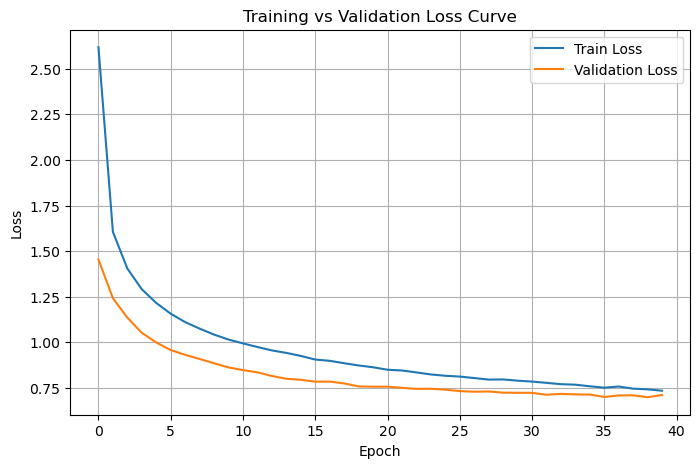

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Comparing Loss on test data

In [17]:
test_metrics = model.evaluate(X_test, y_test_dict, verbose=1)
results = dict(zip(model.metrics_names, test_metrics))
for key, val in results.items():
    print(f"{key}: {val:.4f}")

1574/1574 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - cluster_homogeneity_accuracy: 0.9883 - cluster_homogeneity_loss: 0.0278 - inflammation_label_accuracy: 0.9584 - inflammation_label_loss: 0.1034 - loss: 0.6968 - malignant_label_accuracy: 0.9883 - malignant_label_loss: 0.0280 - malignant_subtype_accuracy: 0.9665 - malignant_subtype_loss: 0.0825 - necrosis_label_accuracy: 0.9908 - necrosis_label_loss: 0.0238 - non_malignant_subtype_accuracy: 0.9703 - non_malignant_subtype_loss: 0.0738 - second_malignant_subtype_accuracy: 0.9539 - second_malignant_subtype_loss: 0.1132 - second_non_malignant_subtype_accuracy: 0.9755 - second_non_malignant_subtype_loss: 0.0596 - stromal_cellularity_accuracy: 0.9612 - stromal_cellularity_loss: 0.0940 - stromal_epithelium_ratio_accuracy: 0.9619 - stromal_epithelium_ratio_loss: 0.0905
loss: 0.6968
compile_metrics: 0.0278
cluster_homogeneity_loss: 0.0280
malignant_label_loss: 0.1034
inflammation_label_loss: 0.0238
necrosis_label_loss: 0.0905
stromal_epithelium_ratio_

In [18]:
model.save('hierarchical_classifier_best.keras')

Running Model on Test Data

In [21]:


# Get predictions for all output heads
preds = model.predict(X_test)

# If you have multiple heads, model.predict returns a list of arrays
# Each array has shape (num_samples, num_classes)
# Convert each output's probability to class index
y_pred_dict = {}
for i, col in enumerate(label_cols):
    y_pred_dict[col] = np.argmax(preds[i], axis=1)

1574/1574 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


Confusion Matrix 

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

for col in label_cols:
    print(f"\n====== Confusion Matrix for: {col} ======\n")

    y_true = Y_test_original[col]
    y_pred = y_pred_dict[col]

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)


    # Optional: classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


====== Confusion Matrix for: cluster_homogeneity ======



TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['high (> 75%)' 'moderate (50 - 75%)'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.

In [29]:
decoded_preds[col] = le.inverse_transform(y_pred_dict[col])

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

for col in label_cols:
    print(f"\n====== Confusion Matrix for: {col} ======\n")

    # True labels = original text
    y_true = Y_test_original[col].values

    # Predicted labels = decoded text from model
    y_pred = decoded_preds[col]

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


====== Confusion Matrix for: cluster_homogeneity ======

[[    0     0     0     0]
 [    0     0     0     0]
 [46015   391     0     0]
 [  196  3755     0     0]]

Classification Report:
                     precision    recall  f1-score   support

       collagenosis       0.00      0.00      0.00       0.0
          elastosis       0.00      0.00      0.00       0.0
       high (> 75%)       0.00      0.00      0.00   46406.0
moderate (50 - 75%)       0.00      0.00      0.00    3951.0

           accuracy                           0.00   50357.0
          macro avg       0.00      0.00      0.00   50357.0
       weighted avg       0.00      0.00      0.00   50357.0


====== Confusion Matrix for: malignant_label ======



/hpc-home/home/users/vpandya/mamba_envs/mamba/envs/jupyter_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hpc-home/home/users/vpandya/mamba_envs/mamba/envs/jupyter_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hpc-home/home/users/vpandya/mamba_envs/mamba/envs/jupyter_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

[[20267   221]
 [  369 29500]]

Classification Report:
              precision    recall  f1-score   support

          no       0.98      0.99      0.99     20488
         yes       0.99      0.99      0.99     29869

    accuracy                           0.99     50357
   macro avg       0.99      0.99      0.99     50357
weighted avg       0.99      0.99      0.99     50357


====== Confusion Matrix for: inflammation_label ======

[[ 9180   214   165]
 [  263 18487   693]
 [  167   595 20593]]

Classification Report:
               precision    recall  f1-score   support

       marked       0.96      0.96      0.96      9559
mild-moderate       0.96      0.95      0.95     19443
  none-sparse       0.96      0.96      0.96     21355

     accuracy                           0.96     50357
    macro avg       0.96      0.96      0.96     50357
 weighted avg       0.96      0.96      0.96     50357


====== Confusion Matrix for: necrosis_label ======

[[45322   185    66]
 [  137  27

In [ ]:
# from sklearn.metrics import classification_report

# reports = {}
# for i, name in enumerate(model.output_names):
#     y_true = y_test_dict[name]
#     y_pred = np.argmax(flat_preds[i], axis=1)
#     reports[name] = classification_report(y_true, y_pred, output_dict=True)

# print(" All reports generated:", list(reports.keys()))

 All reports generated: ['cluster_homogeneity', 'malignant_label', 'inflammation_label', 'necrosis_label', 'stromal_epithelium_ratio', 'stromal_cellularity', 'malignant_subtype', 'second_malignant_subtype', 'non_malignant_subtype', 'second_non_malignant_subtype']


In [ ]:
# with open("evaluation_reports.txt", "w") as f:
#     for i, name in enumerate(model.output_names):
#         y_true = y_test_dict[name]
#         y_pred = np.argmax(flat_preds[i], axis=1)
#         f.write(f"\n=== {name.upper()} ===\n")
#         f.write(classification_report(y_true, y_pred, digits=4))
#         f.write("\n" + "-"*60 + "\n")

In [ ]:
from tensorflow import keras

MODEL_PATH = "/nfs/home/users/vpandya/hierarchical_classifier_best.keras"

model = keras.models.load_model(MODEL_PATH)
output_names = model.output_names  # this matches the ListWrapper order
y_pred_dict = {}

for i, name in enumerate(output_names):
    y_pred_dict[name] = np.argmax(preds[i], axis=1)print("Model loaded!")

2025-11-27 18:04:40.731307: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded!


In [38]:

output_names = model.output_names  # this matches the ListWrapper order
y_pred_dict = {}

for i, name in enumerate(output_names):
    y_pred_dict[name] = np.argmax(preds[i], axis=1)


decoded_preds = {}

for name in output_names:
    le = encoders[name]  # the saved LabelEncoder for this head
    decoded_preds[name] = le.inverse_transform(y_pred_dict[name])

In [39]:
for name in output_names:
    print(f"\n==== Decoded predictions for {name} ====")
    print(decoded_preds[name][:10])   # first 10


==== Decoded predictions for cluster_homogeneity ====
['high (> 75%)' 'high (> 75%)' 'high (> 75%)' 'high (> 75%)'
 'high (> 75%)' 'moderate (50 - 75%)' 'high (> 75%)' 'high (> 75%)'
 'high (> 75%)' 'high (> 75%)']

==== Decoded predictions for malignant_label ====
['yes' 'yes' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'no' 'yes']

==== Decoded predictions for inflammation_label ====
['mild-moderate' 'none-sparse' 'none-sparse' 'none-sparse' 'none-sparse'
 'none-sparse' 'none-sparse' 'none-sparse' 'none-sparse' 'none-sparse']

==== Decoded predictions for necrosis_label ====
['some' 'none' 'none' 'none' 'none' 'some' 'none' 'none' 'none' 'none']

==== Decoded predictions for stromal_epithelium_ratio ====
['more epithelium' 'roughly equal' 'more stroma' 'not_applicable'
 'roughly equal' 'not_applicable' 'more stroma' 'not_applicable'
 'not_applicable' 'more epithelium']

==== Decoded predictions for stromal_cellularity ====
['low' 'high' 'low' 'not_applicable' 'high' 'not_applicable' 'low'
 'no